<a href="https://colab.research.google.com/github/NAHYEONKIM-nyo/DataAnalysis/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EA%B8%B0%EB%B0%98_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_%EC%A4%91%EA%B0%84%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### **1-2. Python을 사용하여 API를 호출하는 코드를 작성하고, 2015년 1월부터 2024년 12월까지의 개인 유형의 현년 전기, 가스, 수도, 지역난방 에너지 사용량 데이터를 수집하는 프로그램을 작성하시오. API 호출 성공을 확인할 수 있는 실행 결과를 캡처하여 첨부하시오. (7점)**

In [ ]:
import requests
import json

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/43/882/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
}

## 데이터 수집
response = requests.get(url, params=params)

## 호출 성공/실패 출력
print(response.json())

data = response.json()
energy_data_list = data['energyUseDataSummaryInfo']['row']

for item in energy_data_list:
    ## YEAR 값을 숫자로 변환
    year_int = int(item['YEAR'])

    ## MM_TYPE이 '개인'이고, 2015년 1월부터 2024년 12월 사이 데이터 수집
    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        mon = item['MON']
        eus = item['EUS']
        gus = item['GUS']
        wus = item['WUS']
        hus = item['HUS']

        print(f"년도: {year_int}년 {mon}월")
        print(f"  - 전기 사용량(EUS): {eus}")
        print(f"  - 가스 사용량(GUS): {gus}")
        print(f"  - 수도 사용량(WUS): {wus}")
        print(f"  - 지역난방 사용량(HUS): {hus}")
        print("-" * 20)

{'energyUseDataSummaryInfo': {'list_total_count': 1241, 'RESULT': {'CODE': 'INFO-000', 'MESSAGE': '정상 처리되었습니다'}, 'row': [{'YEAR': '2024', 'MON': '12', 'MM_TYPE': '공동주택관리소', 'CNT': '3716', 'EUS': '548480228', 'EUS1': '557799290', 'EUS2': '559693904', 'ECO2_1': '-10266369', 'ECO2_2': '-10266369', 'GUS': '8221238', 'GUS1': '9759209', 'GUS2': '9093999', 'GCO2_1': '-1114991.5', 'GCO2_2': '-2229983', 'WUS': '20262147.7', 'WUS1': '20228097.5', 'WUS2': '20488646.8', 'WCO2_1': '-96224.45', 'WCO2_2': '-288673.35', 'HUS': '0', 'HUS1': '0', 'HUS2': '0', 'HCO2_1': '0', 'HCO2_2': '0', 'REG_DATE': '2025-03-01 04:02:55.0'}, {'YEAR': '2024', 'MON': '12', 'MM_TYPE': '소상공인', 'CNT': '53031', 'EUS': '101773064', 'EUS1': '105830842', 'EUS2': '106996097', 'ECO2_1': '-4640405.5', 'ECO2_2': '-4640315.356', 'GUS': '2544825', 'GUS1': '2719970', 'GUS2': '2842004', 'GCO2_1': '-234683', 'GCO2_2': '-469366', 'WUS': '1560686.6', 'WUS1': '1540086.6', 'WUS2': '1542971', 'WCO2_1': '19157.8', 'WCO2_2': '57349.338', 'HUS'

##### **2-1. 수집한 JSON 형태의 데이터를 pandas DataFrame으로 변환하고, 데이터의 기본 정보를 출력하는 코드와 실행 결과를 첨부하시오. (4점)**

In [ ]:
import requests
import json
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
    }

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()

original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}

for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])

    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict

final_output = {'personal': date_keyed_data}

## json 파일 열기
file_path = 'personal_energy_data.json'
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

print("DataFrame 기본 정보(df.info())")
df.info()

print(df)

DataFrame 기본 정보(df.info())
<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 2024-12 to 2015-01
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   EUS     120 non-null    float64
 1   GUS     120 non-null    float64
 2   WUS     120 non-null    float64
 3   HUS     120 non-null    float64
dtypes: float64(4)
memory usage: 4.7+ KB
                 EUS         GUS           WUS           HUS
2024-12  134828126.0  42103424.0  7.326854e+06  1.513199e+06
2024-11  257927956.0  17418221.0  1.467867e+07  8.836296e+06
2024-10  282268119.0   8233421.0  1.529767e+07  2.695491e+06
2024-09  409872908.0   5729131.0  1.514332e+07  3.420507e+06
2024-08  463971328.0   7072251.0  1.587354e+07  1.300823e+05
...              ...         ...           ...           ...
2015-05  177289769.0  22060892.0  1.308673e+07  1.320896e+06
2015-04  183891769.0  37306841.0  1.295477e+07  5.836003e+06
2015-03  175215719.0  49984873.0  1.265547e+07  1.38

#### **2-2. 연도별, 계절별 분석을 위해 날짜 컬럼을 활용하여 연도(year)와 계절(season)컬럼을 추가하는 전처리 코드를 작성하고, 변환 결과를 확인할 수 있는 출력 결과를 첨부하시오.※계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월) (4점)**

In [ ]:
import requests
import json
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
    }

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()

original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}

for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])

    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict

final_output = {'personal': date_keyed_data}

## json 파일 열기
file_path = 'personal_energy_data.json'
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

## 'month' 컬럼 생성
df['month'] = df.index.str[5:].astype(int)

## 'month'로 계절 분류
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else: # 12, 1, 2월
        return '겨울'

## 'year' 컬럼 추가
df['year'] = df.index.str[:4].astype(int)

##'season' 컬럼 추가
df['season'] = df['month'].apply(get_season)

## 전처리에 사용된 'month' 컬럼 삭제
df = df.drop(columns='month')

print(df)

                 EUS         GUS           WUS           HUS  year season
2024-12  134828126.0  42103424.0  7.326854e+06  1.513199e+06  2024     겨울
2024-11  257927956.0  17418221.0  1.467867e+07  8.836296e+06  2024     가을
2024-10  282268119.0   8233421.0  1.529767e+07  2.695491e+06  2024     가을
2024-09  409872908.0   5729131.0  1.514332e+07  3.420507e+06  2024     가을
2024-08  463971328.0   7072251.0  1.587354e+07  1.300823e+05  2024     여름
...              ...         ...           ...           ...   ...    ...
2015-05  177289769.0  22060892.0  1.308673e+07  1.320896e+06  2015      봄
2015-04  183891769.0  37306841.0  1.295477e+07  5.836003e+06  2015      봄
2015-03  175215719.0  49984873.0  1.265547e+07  1.382635e+07  2015      봄
2015-02  189974230.0  56487358.0  1.265689e+07  1.879332e+07  2015     겨울
2015-01  193784708.0  59133720.0  1.281976e+07  2.274084e+07  2015     겨울

[120 rows x 6 columns]


#### **3-1. 연도별 에너지 사용 총 사용량(전기+가스+수도+지역난방) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오. (예: "연도별 에너지 사용 총액 변화 - 1234") 시각화 코드와 생성된 그래프를 첨부하시오. (4점)**

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

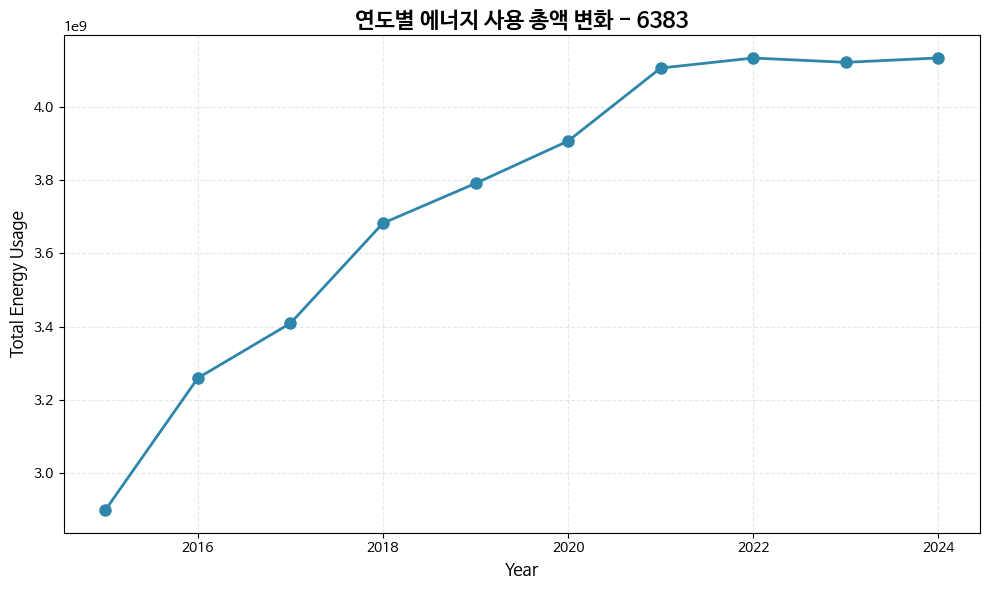

In [5]:
## 한국어 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf


import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

## 한국어 폰트 설정
plt.rc('font', family='NanumBarunGothic')

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()
original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}
for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])
    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict
final_output = {'personal': date_keyed_data}

## json 파일 저장 (읽기 전에 저장 추가)
file_path = 'personal_energy_data.json'
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(final_output, f, ensure_ascii=False, indent=4)

## json 파일 열기
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

## 'month' 컬럼 생성
df['month'] = df.index.str[5:].astype(int)

## 'month'로 계절 분류
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:  # 12, 1, 2월
        return '겨울'

## 'year' 컬럼 추가
df['year'] = df.index.str[:4].astype(int)
## 'season' 컬럼 추가
df['season'] = df['month'].apply(get_season)
## 전처리에 사용된 'month' 컬럼 삭제
df = df.drop(columns='month')

# 연도별 총 에너지 사용량 라인 플롯

# 총 에너지 사용량 계산 (EUS + GUS + WUS + HUS)
df['total_energy'] = df['EUS'] + df['GUS'] + df['WUS'] + df['HUS']
# 연도별 총 에너지 사용량 계산
yearly_total = df.groupby('year')['total_energy'].sum()

# 라인 플롯 생성
plt.figure(figsize=(10, 6))
plt.plot(yearly_total.index, yearly_total.values, marker='o', linewidth=2, markersize=8, color='#2E86AB')
plt.title('연도별 에너지 사용 총액 변화 - 6383', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Energy Usage', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# 플롯 저장
plt.show()

#### **3-2. 계절별 가스 사용량 평균을 막대 그래프로 시각화하고, 각 막대에 구체적인 수치를 표시하시오. 시각화 코드와 생성된 그래프를 첨부하시오. (4점)**

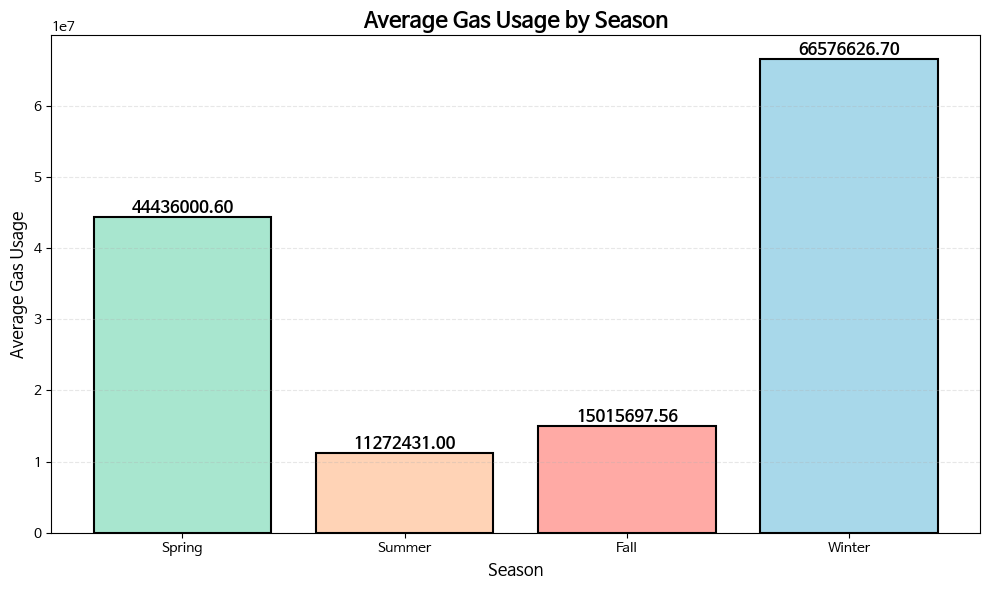

In [7]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

## 데이터 수집 url 및 api key 설정
url = 'http://openapi.seoul.go.kr:8088/5a774361516e61683733784e4b6978/json/energyUseDataSummaryInfo/1/1000/'
api_key = '5a774361516e61683733784e4b6978'
params = {
    'Key': api_key,
    'Type': 'json',
    'Service': 'energyUseDataSummaryInfo',
    'START_INDEX': '43',
    'END_INDEX': '882'
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()
original_data_list = data['energyUseDataSummaryInfo']['row']

## 날짜별 데이터를 담을 딕셔너리
date_keyed_data = {}
for item in original_data_list:
    year_int = int(item['YEAR'])
    mon_int = int(item['MON'])
    if item['MM_TYPE'] == '개인' and 2015 <= year_int <= 2024:
        key = f"{year_int}-{mon_int:02d}"
        value_dict = {
            'EUS': float(item['EUS']), 'GUS': float(item['GUS']),
            'WUS': float(item['WUS']), 'HUS': float(item['HUS'])
        }
        date_keyed_data[key] = value_dict
final_output = {'personal': date_keyed_data}

## json 파일 저장 (읽기 전에 저장 추가)
file_path = 'personal_energy_data.json'
with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(final_output, f, ensure_ascii=False, indent=4)

## json 파일 열기
with open(file_path, 'r', encoding='utf-8') as f:
    loaded_data = json.load(f)

## 'personal'데이터를 Pandas DataFrame으로 변환
df = pd.DataFrame.from_dict(loaded_data['personal'], orient='index')

## 'month' 컬럼 생성
df['month'] = df.index.str[5:].astype(int)

## 'month'로 계절 분류
def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:  # 12, 1, 2월
        return '겨울'

## 'year' 컬럼 추가
df['year'] = df.index.str[:4].astype(int)
## 'season' 컬럼 추가
df['season'] = df['month'].apply(get_season)
## 전처리에 사용된 'month' 컬럼 삭제
df = df.drop(columns='month')

# 계절별 평균 가스 사용량 바 플롯

# 계절별 평균 가스 사용량 계산
season_gas_avg = df.groupby('season')['GUS'].mean()

# 한글 계절명을 영어로 매핑
season_mapping = {'봄': 'Spring', '여름': 'Summer', '가을': 'Fall', '겨울': 'Winter'}
season_gas_avg_en = season_gas_avg.copy()
season_gas_avg_en.index = season_gas_avg_en.index.map(season_mapping)

# 계절 순서 재정렬
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_gas_avg_en = season_gas_avg_en.reindex(season_order)

# 바 플롯 생성
plt.figure(figsize=(10, 6))
bars = plt.bar(season_gas_avg_en.index, season_gas_avg_en.values, color=['#A8E6CF', '#FFD3B6', '#FFAAA5', '#A8D8EA'], edgecolor='black', linewidth=1.5)

# 각 막대 위에 값 표시
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Average Gas Usage by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Gas Usage', fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

# 플롯 저장
plt.show()